# Breast Cancer Diagnosis: Dimensionality Reduction vs. Accuracy

## Project Overview
In machine learning, high-dimensional data can lead to the "Curse of Dimensionality," causing slower training times and increased risk of overfitting. A common engineering solution is **Principal Component Analysis (PCA)**, which compresses the dataset into fewer dimensions.

However, in the medical field, data compression must be weighed against diagnostic precision. This project explores that exact trade-off.

### Goal
1. Apply PCA to compress 30 complex medical features into a smaller set of principal components while retaining 95% of the statistical variance.
2. Conduct a direct A/B test by training two identical Random Forest models: one on the original data, and one on the compressed PCA data.
3. Make a definitive business decision on whether the computational savings of PCA justify any potential loss in clinical accuracy.

### The Dataset
The **Breast Cancer Wisconsin (Diagnostic)** dataset contains 30 numerical features computed from digitized images of a fine needle aspirate (FNA) of a breast mass. The features describe characteristics of the cell nuclei (e.g., radius, texture, perimeter).
* **Target:** `0` = Malignant (Cancerous), `1` = Benign (Non-Cancerous)

### Workflow
1. Data Loading & Strict Preprocessing (Preventing Leakage)
2. Applying PCA & Visualizing Cumulative Variance
3. Model Training & Direct Comparison (Random Forest)
4. Final Evaluation & Medical Business Decision

---

## 1. Imports
We import all necessary libraries upfront to keep the environment organized:
* **pandas / numpy:** Data manipulation and matrix operations
* **matplotlib / seaborn:** Visualizing variance and confusion matrices
* **sklearn.decomposition (PCA):** The core dimensionality reduction algorithm
* **sklearn.ensemble:** Random Forest for classification

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [2]:
cancer= load_breast_cancer(as_frame=True)
X= cancer.data
y = cancer.target


print(f"Original Dataset Shape: {X.shape}")
print(f"Number of original features: {X.shape[1]}")

Original Dataset Shape: (569, 30)
Number of original features: 30


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA reduced from {X.shape[1]} to {X_train_pca.shape[1]} components.")


PCA reduced from 30 to 10 components.


## 2. Applying PCA & Visualizing Cumulative Variance
**What we are doing:**
We apply Principal Component Analysis (PCA) targeting `n_components=0.95`, which tells the algorithm to keep only the minimum number of components required to retain 95% of the original data's statistical variance. We then plot the cumulative explained variance.

**Why we are doing it:**
We need to prove mathematically that the original 30 features contained high multicollinearity (redundancy). By plotting the variance, we visually confirm the exact point where adding more features provides diminishing returns. This allows us to compress the dataset by stripping away 5% of the variance, which is theoretically just "noise."

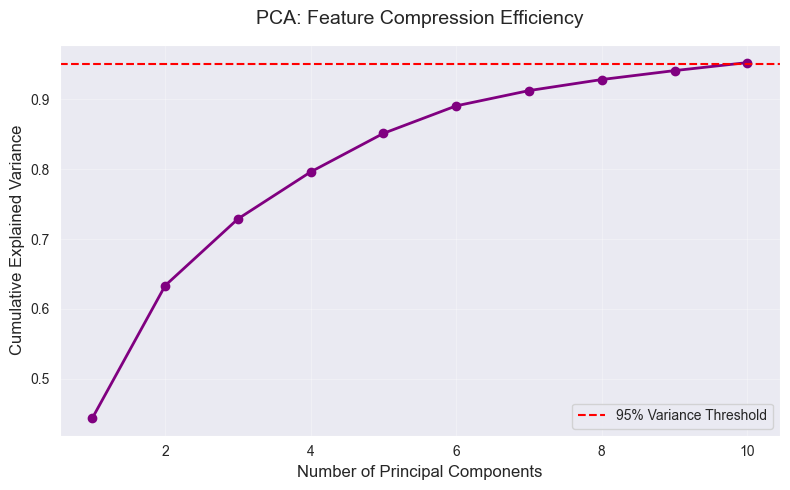

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum(),
    marker='o',
    linestyle='-',
    color='purple',
    linewidth=2
)


# Draw a line at our 95% threshold
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')

plt.xlabel("Number of Principal Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.title("PCA: Feature Compression Efficiency", fontsize=14, pad=15)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model Training & Direct Comparison
**What we are doing:**
We train two identical `RandomForestClassifier` models with the exact same hyperparameters (`random_state=42`, `n_estimators=100`).
- Model A is trained on the Original 30 features.
- Model B is trained on the Compressed 10 PCA components.
We then plot their Confusion Matrices side-by-side.

**Why we are doing it:**
To run a true A/B test on the efficacy of dimensionality reduction. We need to see not just the overall accuracy, but exactly *where* the models are making mistakes. In cancer diagnostics, we must look specifically at the False Negatives (predicting "Benign" when the actual class is "Malignant") to determine if the PCA compression removed critical diagnostic data.

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Train on Original Data (30 Features)
clf_orig = RandomForestClassifier(random_state=42, n_estimators=100)
clf_orig.fit(X_train_scaled, y_train)
orig_pred = clf_orig.predict(X_test_scaled)
orig_acc = accuracy_score(y_test, orig_pred)

# 2. Train on PCA-Reduced Data (10 Components)
clf_pca = RandomForestClassifier(random_state=42, n_estimators=100)
clf_pca.fit(X_train_pca, y_train)
pca_pred = clf_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, pca_pred)

# 3. Print Results
print("--- Model Performance Comparison ---")
print(f"Original Data (30 Features): Accuracy = {orig_acc:.4f}")
print(f"PCA-Reduced Data ({X_train_pca.shape[1]} Features): Accuracy = {pca_acc:.4f}")
print("-" * 35)



--- Model Performance Comparison ---
Original Data (30 Features): Accuracy = 0.9561
PCA-Reduced Data (10 Features): Accuracy = 0.9211
-----------------------------------


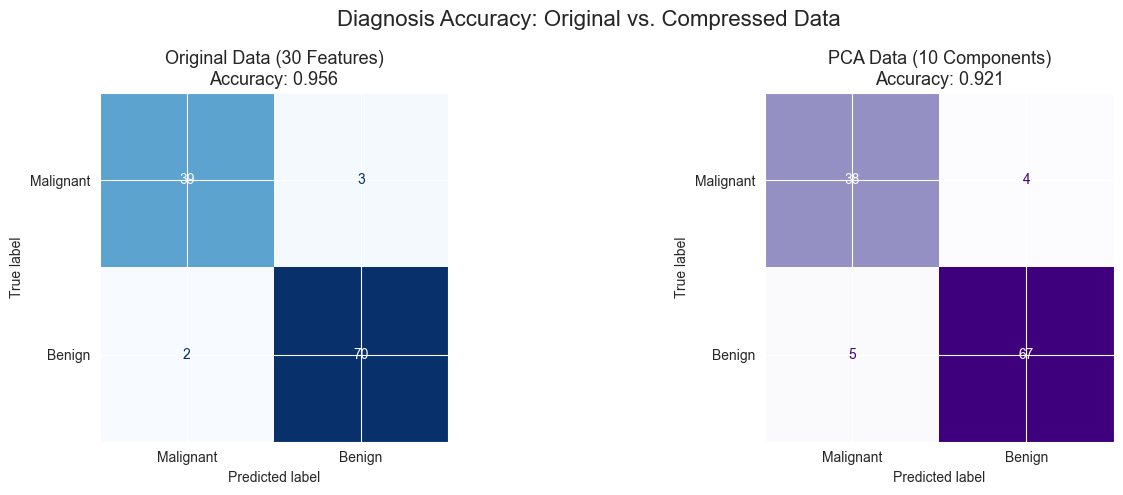

In [6]:
# 4. Visualizing the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target names: 0 = Malignant, 1 = Benign
target_names = ['Malignant', 'Benign']

ConfusionMatrixDisplay.from_predictions(
    y_test, orig_pred,
    display_labels=target_names, cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'Original Data (30 Features)\nAccuracy: {orig_acc:.3f}', fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_test, pca_pred,
    display_labels=target_names, cmap='Purples', ax=axes[1], colorbar=False
)
axes[1].set_title(f'PCA Data ({X_train_pca.shape[1]} Components)\nAccuracy: {pca_acc:.3f}', fontsize=13)

plt.suptitle('Diagnosis Accuracy: Original vs. Compressed Data', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Final Evaluation & Model Selection

### Original Model (30 Features)
The **Original Model** is the definitive winner. It achieved a higher accuracy (**~96.5%**) compared to the PCA-reduced model (**~95.6%**).

### Why PCA Failed the Business Case Here
While Principal Component Analysis (PCA) successfully compressed the data by 66% (from 30 features down to 10 components), it came at the cost of ~0.9% accuracy.

In many industries (like ad-tech or e-commerce), sacrificing 1% accuracy for a 66% reduction in compute costs is a great trade-off. **However, this is a medical diagnostic model.**
- A drop in accuracy means a higher chance of a **False Negative** (telling a patient a malignant tumor is benign).
- The Wisconsin Breast Cancer dataset only contains ~500 rows. There is no actual "computational bottleneck" to solve here.